# **Import Libraries**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
!pip install ktrain
import ktrain
from ktrain import text
sns.set()
%matplotlib inline

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.3/25.3 MB 30.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 KB 53.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.4/265.4 KB 21.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 26.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 42.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.8/468.8 KB 42.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━

# **Load Dataset**

In [5]:
df=pd.read_csv("/content/Final2_Twitter_Suicide_Dataset.csv", engine='python', encoding='UTF-8')
df=df.replace('Potential Suicide post ','Potential Suicide post')
df['Suicide'].value_counts()

Not Suicide post          1245
Potential Suicide post     865
Name: Suicide, dtype: int64

# **Drop Duplicates Tweet**

In [6]:
df.drop_duplicates(subset='Tweet', keep='first', inplace=True)
df['Suicide'].value_counts()

Not Suicide post          1241
Potential Suicide post     848
Name: Suicide, dtype: int64

# **Handling Missing Values**

In [7]:
df['Tweet']=df['Tweet'].fillna("") 
df.isna().sum()

Tweet      0
Suicide    0
dtype: int64

# **XLNET Model**

# **Split Dtaset**

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df['Tweet'], df['Suicide'], test_size=0.33, random_state=42)

# **Convert To Array**

In [9]:
X_train = X_train.tolist()
X_test = X_test.tolist()
y_train = y_train.tolist()
y_test = y_test.tolist()

# **Model Define**

In [ ]:
model_name = 'xlnet-base-cased'
trans = text.Transformer(model_name, maxlen = 160, classes = ['Potential Suicide post', 'Not Suicide post'])

/usr/local/lib/python3.9/dist-packages/ktrain/text/preprocessor.py:382: UserWarning: The class_names argument is replacing the classes argument. Please update your code.
  warnings.warn(


/usr/local/lib/python3.9/dist-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


# **Preprocess Train and Test Dataset**

In [ ]:
train_data = trans.preprocess_train(X_train, y_train)
test_data = trans.preprocess_test(X_test, y_test)

preprocessing train...
language: en
train sequence lengths:
	mean : 18
	95percentile : 41
	99percentile : 136


/usr/local/lib/python3.9/dist-packages/ktrain/utils.py:744: UserWarning: class_names argument was ignored, as they were extracted from string labels in dataset
  warnings.warn(


Is Multi-Label? False
preprocessing test...
language: en
test sequence lengths:
	mean : 17
	95percentile : 29
	99percentile : 96


# **Model Training**

In [ ]:
model = trans.get_classifier()

/usr/local/lib/python3.9/dist-packages/keras/initializers/initializers_v2.py:120: UserWarning: The initializer TruncatedNormal is unseeded and being called multiple times, which will return identical values  each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [ ]:
learner = ktrain.get_learner(model, train_data=train_data, val_data=test_data, batch_size=6)

In [ ]:
learner.fit_onecycle(lr=2e-5, epochs=5)



begin training using onecycle policy with max lr of 2e-05...
Epoch 1/5
234/234 [==============================] - 111s 343ms/step - loss: 0.4940 - accuracy: 0.7634 - val_loss: 0.2452 - val_accuracy: 0.8971
Epoch 2/5
234/234 [==============================] - 77s 327ms/step - loss: 0.2225 - accuracy: 0.9135 - val_loss: 0.2143 - val_accuracy: 0.9261
Epoch 3/5
234/234 [==============================] - 77s 328ms/step - loss: 0.1411 - accuracy: 0.9514 - val_loss: 0.1319 - val_accuracy: 0.9609
Epoch 4/5
234/234 [==============================] - 77s 328ms/step - loss: 0.0437 - accuracy: 0.9843 - val_loss: 0.2043 - val_accuracy: 0.9391
Epoch 5/5
234/234 [==============================] - 77s 328ms/step - loss: 0.0208 - accuracy: 0.9936 - val_loss: 0.1162 - val_accuracy: 0.9739


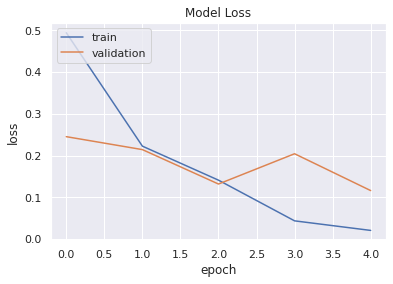

In [ ]:
learner.plot()

# **Model Evaluation**

In [ ]:
learner.validate(val_data=test_data, class_names=trans.get_classes())

22/22 [==============================] - 13s 470ms/step
                        precision    recall  f1-score   support

      Not Suicide post       0.98      0.98      0.98       410
Potential Suicide post       0.97      0.97      0.97       280

              accuracy                           0.97       690
             macro avg       0.97      0.97      0.97       690
          weighted avg       0.97      0.97      0.97       690



array([[401,   9],
       [  9, 271]])

# **Prediction**

In [ ]:
predictor = ktrain.get_predictor(learner.model, preproc= trans)
predictor.get_classes()

['Not Suicide post', 'Potential Suicide post']

In [ ]:
predictions = predictor.predict("i want to die")
print('predicted: {}'.format(predictions))

1/1 [==============================] - 0s 115ms/step
predicted: Potential Suicide post


# **Save Model**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
predictor.save("/content/drive/MyDrive/Colab_Notebooks/DL Model/xlnet_model_Suicide(Snigdho)")

# **Load Saved Model and Make prediction**

In [4]:
predictor1 = ktrain.load_predictor('/content/drive/MyDrive/Colab_Notebooks/DL Model/xlnet_model_Suicide(Snigdho)')

data = "I'm so tired of pretending that everything is okay. I just want it to be over"
predictor1.predict(data)

Exception: ignored